In [42]:
# gerar 30 shared base restricao a direita p_i <= c

import json
import random
import numpy as np

candidato_template = {
    "name": "",
    "given": "p1 >= c AND p2 >= c AND p3 >= c AND p4 >= c AND p5 >= c",
    "when": "p6 >= 0",
    "do": "action_x",
    "then": "p7 >= c AND p8 >= c AND p9 >= c AND p10 >= c AND p11 >= c",
    
}

def gerar_c_primos(c, n, std, min_v=0, max_v=100, seed=None):
    if seed is not None:
        random.seed(seed)
    cs = []
    for _ in range(n):
        while True:
            valor = random.normalvariate(c, std)
            # Trunca para o intervalo, mas só aceita se NÃO for exatamente min_v ou max_v
            valor_trunc = max(min(valor, max_v), min_v)
            if valor_trunc != min_v and valor_trunc != max_v:
                cs.append(valor_trunc)
                break
            # Senão, sorteia de novo
    return cs
# Parâmetros principais
n_candidatos = 100

std_dict = {
    "baixo": 3,
    "medio": 15,
    "alto": 35
}

# Inicializa listas vazias para cada nível
candidatos_por_nivel = {
    "baixo": [],
    "medio": [],
    "alto": []
}

# Listas para guardar os desvios padrão dos grupos de cada nível
stds_por_nivel = {
    "baixo": [],
    "medio": [],
    "alto": []
}

for index_grupo in range(30):
    c = random.uniform(0.1, 99.9)
    for nivel, std in std_dict.items():
        c_primos = gerar_c_primos(c, n_candidatos, std)
        std_real = np.std(c_primos)
        stds_por_nivel[nivel].append(std_real)
        print(f"\nNível: {nivel.upper()} - std={std} | Desvio padrão real: {std_real:.2f}")
        candidatos = []
        for i, c_val in enumerate(c_primos):
            candidato = candidato_template.copy()
            candidato["name"] = f"candidato_{nivel}_{index_grupo+1}_{i+1}"
            c_str = f"{c_val:.2f}"
            candidato["given"] = candidato_template["given"].replace("c", c_str)
            candidato["then"] = candidato_template["then"].replace("c", c_str)
            candidatos.append(candidato)
        candidatos_por_nivel[nivel].append(candidatos)

# Mostra a média dos desvios padrão de cada nível
print("\n" + "="*40)
for nivel in std_dict:
    media_std = np.mean(stds_por_nivel[nivel])
    print(f"MÉDIA dos desvios padrão dos grupos ({nivel.upper()}): {media_std:.2f}")
print("="*40 + "\n")

# Salvar em arquivo JSON
with open("candidatos_por_nivel.json", "w", encoding="utf-8") as f:
    json.dump(candidatos_por_nivel, f, ensure_ascii=False, indent=2)



Nível: BAIXO - std=3 | Desvio padrão real: 2.89

Nível: MEDIO - std=15 | Desvio padrão real: 12.19

Nível: ALTO - std=35 | Desvio padrão real: 22.82

Nível: BAIXO - std=3 | Desvio padrão real: 2.96

Nível: MEDIO - std=15 | Desvio padrão real: 9.49

Nível: ALTO - std=35 | Desvio padrão real: 22.40

Nível: BAIXO - std=3 | Desvio padrão real: 2.78

Nível: MEDIO - std=15 | Desvio padrão real: 13.02

Nível: ALTO - std=35 | Desvio padrão real: 23.65

Nível: BAIXO - std=3 | Desvio padrão real: 2.82

Nível: MEDIO - std=15 | Desvio padrão real: 12.11

Nível: ALTO - std=35 | Desvio padrão real: 26.47

Nível: BAIXO - std=3 | Desvio padrão real: 2.66

Nível: MEDIO - std=15 | Desvio padrão real: 14.88

Nível: ALTO - std=35 | Desvio padrão real: 23.84

Nível: BAIXO - std=3 | Desvio padrão real: 3.04

Nível: MEDIO - std=15 | Desvio padrão real: 12.90

Nível: ALTO - std=35 | Desvio padrão real: 26.70

Nível: BAIXO - std=3 | Desvio padrão real: 3.07

Nível: MEDIO - std=15 | Desvio padrão real: 12.77



In [43]:
import json

# 1. Ler o arquivo agrupado por nível e grupo
with open("candidatos_por_nivel.json", "r", encoding="utf-8") as f:
    dados = json.load(f)

# 2. Extrair todos os candidatos para uma lista única
todos_candidatos = []
for nivel_lista in dados.values():
    for grupo in nivel_lista:     # grupo é uma lista de candidatos
        todos_candidatos.extend(grupo)

# 3. Salvar como shared_scenarios.json
with open("shared_scenarios.json", "w", encoding="utf-8") as f:
    json.dump(todos_candidatos, f, ensure_ascii=False, indent=2)

print(f"Total de candidatos únicos: {len(todos_candidatos)}")


Total de candidatos únicos: 9000


In [44]:
import pandas as pd
import json
import re

# Substitua pelo nome do seu arquivo jsonl
jsonl_file = "similarity_results.jsonl"

# Lista para guardar as informações extraídas
registros = []

with open(jsonl_file, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        diagnosed_name = data["diagnosed"]["name"]
        candidate_name = data["candidate"]["name"]
        candidate_given = data["candidate"]["given"]

 

        match = re.search(r'p1\s*(<=|>=|<|>)\s*([0-9]+(?:\.[0-9]+)?)', candidate_given)
        if match:
            operador, c_linha = match.groups()

        candidate_name

        similarity = data["similarity_result"]
        registros.append({
            "DiagnosedScenario_name": diagnosed_name,
            "CandidateScenario_name": candidate_name,
            "Candidate_given": candidate_given,
            "c_linha": c_linha,
            "similarity": similarity
        })

# Criar DataFrame
df = pd.DataFrame(registros)

split_cols = df["CandidateScenario_name"].str.split('_', expand=True)

# Cria as novas colunas
df['grupo'] = split_cols[1]
df['index_grupo'] = split_cols[2]
df['index_inner_grupo'] = split_cols[3]

df = df[['DiagnosedScenario_name', 'CandidateScenario_name', 
         'grupo', 'index_grupo', 'index_inner_grupo', 
         'Candidate_given', 'c_linha', 'similarity']]


df

,DiagnosedScenario_name,CandidateScenario_name,grupo,index_grupo,index_inner_grupo,Candidate_given,c_linha,similarity
0,direita_baixa,candidato_baixo_1_1,baixo,1,1,p1 >= 82.44 AND p2 >= 82.44 AND p3 >= 82.44 AN...,82.44,0.450399
1,direita_baixa,candidato_baixo_1_2,baixo,1,2,p1 >= 83.44 AND p2 >= 83.44 AND p3 >= 83.44 AN...,83.44,0.443733
2,direita_baixa,candidato_baixo_1_3,baixo,1,3,p1 >= 79.80 AND p2 >= 79.80 AND p3 >= 79.80 AN...,79.80,0.467997
3,direita_baixa,candidato_baixo_1_4,baixo,1,4,p1 >= 83.53 AND p2 >= 83.53 AND p3 >= 83.53 AN...,83.53,0.443133
4,direita_baixa,candidato_baixo_1_5,baixo,1,5,p1 >= 88.85 AND p2 >= 88.85 AND p3 >= 88.85 AN...,88.85,0.407667
...,...,...,...,...,...,...,...,...
26995,direita_alta,candidato_alto_30_96,alto,30,96,p1 >= 19.95 AND p2 >= 19.95 AND p3 >= 19.95 AN...,19.95,0.408285
26996,direita_alta,candidato_alto_30_97,alto,30,97,p1 >= 81.32 AND p2 >= 81.32 AND p3 >= 81.32 AN...,81.32,0.654531
26997,direita_alta,candidato_alto_30_98,alto,30,98,p1 >= 62.64 AND p2 >= 62.64 AND p3 >= 62.64 AN...,62.64,0.493935
26998,direita_alta,candidato_alto_30_99,alto,30,99,p1 >= 82.49 AND p2 >= 82.49 AND p3 >= 82.49 AN...,82.49,0.675993


In [32]:
# # só para testar
# filtro = (
#     (df["DiagnosedScenario_name"] == "direita_alta") &
#     (df["grupo"] == 'alto') &
#     (df["index_grupo"] == "10")  # para index_grupo == 1
# )
# df_filtrado = df[filtro]
# df_filtrado

In [45]:
temp = df.groupby(['DiagnosedScenario_name', 'grupo','index_grupo'], as_index=False).agg({
    'similarity': 'max'
})
temp

,DiagnosedScenario_name,grupo,index_grupo,similarity
0,direita_alta,alto,1,0.927333
1,direita_alta,alto,10,0.921333
2,direita_alta,alto,11,0.931539
3,direita_alta,alto,12,0.833733
4,direita_alta,alto,13,0.920733
...,...,...,...,...
265,direita_media,medio,5,0.929373
266,direita_media,medio,6,0.920733
267,direita_media,medio,7,0.930585
268,direita_media,medio,8,0.914391


In [46]:
tabela = temp.pivot_table(index=['DiagnosedScenario_name', 'index_grupo'], columns='grupo', values='similarity')
tabela['grupo_vencedor'] = tabela[['baixo', 'medio', 'alto']].idxmax(axis=1)
tabela


grupo                                   alto     baixo     medio  \
DiagnosedScenario_name index_grupo                                 
direita_alta           1            0.927333  0.871449  0.921933   
                       10           0.921333  0.929733  0.924933   
                       11           0.931539  0.409389  0.595227   
                       12           0.833733  0.400665  0.445671   
                       13           0.920733  0.512703  0.653133   
...                                      ...       ...       ...   
direita_media          5            0.923253  0.876453  0.929373   
                       6            0.911613  0.814179  0.920733   
                       7            0.922725  0.928809  0.930585   
                       8            0.931533  0.708381  0.914391   
                       9            0.930945  0.898053  0.932853   

grupo                              grupo_vencedor  
DiagnosedScenario_name index_grupo                 
direita_alta           1                     alto  
                       10                   baixo  
                       11                    alto  
                       12                    alto  
                       13                    alto  
...                                           ...  
direita_media          5                    medio  
                       6                    medio  
                       7                    medio  
                       8                     alto  
                       9                    medio  

[90 rows x 4 columns]

In [47]:
vitorias = tabela['grupo_vencedor'].value_counts()
vitorias

grupo_vencedor
alto     63
medio    19
baixo     8
Name: count, dtype: int64

In [48]:
from scipy.stats import friedmanchisquare

# Remova linhas com NaN para que todos os grupos estejam presentes
friedman_result = friedmanchisquare(
    tabela['baixo'].dropna(),
    tabela['medio'].dropna(),
    tabela['alto'].dropna()
)
print(f"Friedman: chi2={friedman_result.statistic:.3f}, p-value={friedman_result.pvalue}")

import plotly.express as px

px.bar(
    vitorias,
    labels={'index': 'Grupo', 'value': 'Nº de vezes com maior similaridade'},
    title="Número de vezes que cada grupo teve a maior similaridade"
).show()


Friedman: chi2=87.616, p-value=9.430059600981225e-20


- Friedman é um teste estatístico não-paramétrico (nao normal) usado para comparar mais de dois grupos pareados.
- Ele verifica se há diferença significativa entre as distribuições dos grupos (a mediana dos ranks dos valores).

- Exemplo clássico:
Imagine que você testa 3 métodos de ensino em 10 alunos e mede a nota de cada aluno em cada método. Como é sempre o “mesmo aluno” sendo comparado, é um dado pareado.

- No seu caso:
Cada linha da tabela é uma comparação para um DiagnosedScenario/index_grupo, e você compara baixo, médio e alto na mesma situação.

In [16]:
# max_sim_df = df.groupby(['DiagnosedScenario_name', 'index_grupo'], as_index=False).agg({
#     'similarity': 'max'
# })

# df_merge = pd.merge(
#     max_sim_df,
#     df[['DiagnosedScenario_name', 'index_grupo', 'grupo', 'similarity']],
#     on=['DiagnosedScenario_name', 'index_grupo', 'similarity'],
#     how='left'
# )

# # Se houver duplicatas (empates), deixa só uma:
# df_merge = df_merge.drop_duplicates(subset=['DiagnosedScenario_name', 'index_grupo'])

# df_merge

In [17]:
# contagem = df_merge['grupo'].value_counts()
# print(contagem)

In [278]:
<><><><><><><><>

SyntaxError: invalid syntax (2122146794.py, line 1)

In [251]:
# Sempre converta ANTES de filtrar ou agrupar!
df['c_linha'] = pd.to_numeric(df['c_linha'], errors='coerce')
df['similarity'] = pd.to_numeric(df['similarity'], errors='coerce')
df['index_grupo'] = pd.to_numeric(df['index_grupo'], errors='coerce')

temp = df[df["DiagnosedScenario_name"] == "direita_baixa"]
temp = temp[temp["grupo"] == "baixo"]

temp



,DiagnosedScenario_name,CandidateScenario_name,grupo,index_grupo,index_inner_grupo,Candidate_given,c_linha,similarity
0,direita_baixa,candidato_baixo_1_1,baixo,1,1,p1 >= 50.13 AND p2 >= 50.13 AND p3 >= 50.13 AN...,50.13,0.665799
1,direita_baixa,candidato_baixo_1_2,baixo,1,2,p1 >= 47.18 AND p2 >= 47.18 AND p3 >= 47.18 AN...,47.18,0.685467
2,direita_baixa,candidato_baixo_1_3,baixo,1,3,p1 >= 47.82 AND p2 >= 47.82 AND p3 >= 47.82 AN...,47.82,0.681201
3,direita_baixa,candidato_baixo_1_4,baixo,1,4,p1 >= 40.40 AND p2 >= 40.40 AND p3 >= 40.40 AN...,40.40,0.730665
4,direita_baixa,candidato_baixo_1_5,baixo,1,5,p1 >= 48.67 AND p2 >= 48.67 AND p3 >= 48.67 AN...,48.67,0.675531
...,...,...,...,...,...,...,...,...
95,direita_baixa,candidato_baixo_1_96,baixo,1,96,p1 >= 42.36 AND p2 >= 42.36 AND p3 >= 42.36 AN...,42.36,0.717597
96,direita_baixa,candidato_baixo_1_97,baixo,1,97,p1 >= 42.02 AND p2 >= 42.02 AND p3 >= 42.02 AN...,42.02,0.719865
97,direita_baixa,candidato_baixo_1_98,baixo,1,98,p1 >= 44.10 AND p2 >= 44.10 AND p3 >= 44.10 AN...,44.10,0.705999
98,direita_baixa,candidato_baixo_1_99,baixo,1,99,p1 >= 44.17 AND p2 >= 44.17 AND p3 >= 44.17 AN...,44.17,0.705531


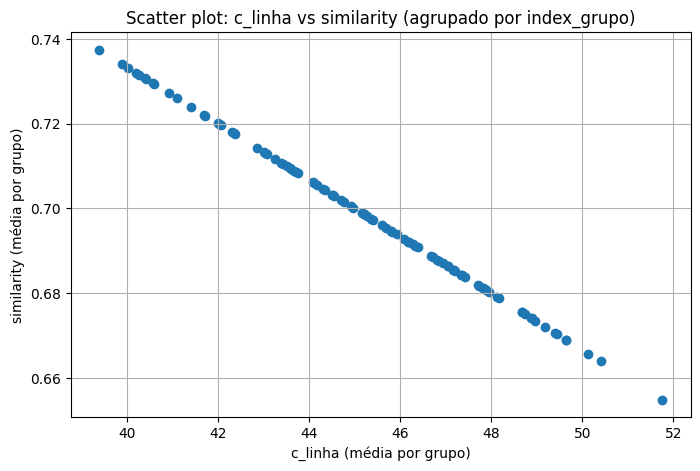

In [252]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(temp['c_linha'], temp['similarity'])
plt.xlabel('c_linha (média por grupo)')
plt.ylabel('similarity (média por grupo)')
plt.title('Scatter plot: c_linha vs similarity (agrupado por index_grupo)')
plt.grid(True)
plt.show()

In [253]:
# Agora pode agrupar
temp = temp.groupby('index_grupo')[['c_linha', 'similarity']].mean().reset_index()
temp = temp.sort_values('similarity', ascending=True)
temp

,index_grupo,c_linha,similarity
0,1,45.2359,0.698427


In [254]:


import plotly.express as px

fig = px.box(
    temp, 
    y='similarity', 
    points="all", 
    title="Boxplot da Similaridade (tudo junto)"
)
fig.show()


In [255]:
temp=df[df["DiagnosedScenario_name"] == "direita_baixa"]
temp=temp[temp["grupo"] == "alto"]

temp['c_linha'] = pd.to_numeric(temp['c_linha'], errors='coerce')
temp['similarity'] = pd.to_numeric(temp['similarity'], errors='coerce')
temp['index_grupo'] = pd.to_numeric(temp['index_grupo'], errors='coerce')

temp


,DiagnosedScenario_name,CandidateScenario_name,grupo,index_grupo,index_inner_grupo,Candidate_given,c_linha,similarity
200,direita_baixa,candidato_alto_1_1,alto,1,1,p1 >= 38.01 AND p2 >= 38.01 AND p3 >= 38.01 AN...,38.01,0.746601
201,direita_baixa,candidato_alto_1_2,alto,1,2,p1 >= 19.29 AND p2 >= 19.29 AND p3 >= 19.29 AN...,19.29,0.871401
202,direita_baixa,candidato_alto_1_3,alto,1,3,p1 >= 53.14 AND p2 >= 53.14 AND p3 >= 53.14 AN...,53.14,0.645735
203,direita_baixa,candidato_alto_1_4,alto,1,4,p1 >= 18.89 AND p2 >= 18.89 AND p3 >= 18.89 AN...,18.89,0.874065
204,direita_baixa,candidato_alto_1_5,alto,1,5,p1 >= 30.74 AND p2 >= 30.74 AND p3 >= 30.74 AN...,30.74,0.795069
...,...,...,...,...,...,...,...,...
295,direita_baixa,candidato_alto_1_96,alto,1,96,p1 >= 83.55 AND p2 >= 83.55 AND p3 >= 83.55 AN...,83.55,0.443001
296,direita_baixa,candidato_alto_1_97,alto,1,97,p1 >= 60.98 AND p2 >= 60.98 AND p3 >= 60.98 AN...,60.98,0.593469
297,direita_baixa,candidato_alto_1_98,alto,1,98,p1 >= 25.66 AND p2 >= 25.66 AND p3 >= 25.66 AN...,25.66,0.828933
298,direita_baixa,candidato_alto_1_99,alto,1,99,p1 >= 4.35 AND p2 >= 4.35 AND p3 >= 4.35 AND p...,4.35,0.897891


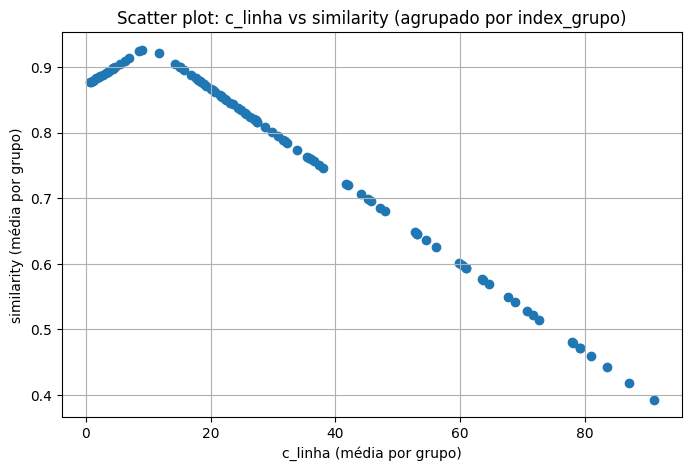

In [256]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(temp['c_linha'], temp['similarity'])
plt.xlabel('c_linha (média por grupo)')
plt.ylabel('similarity (média por grupo)')
plt.title('Scatter plot: c_linha vs similarity (agrupado por index_grupo)')
plt.grid(True)
plt.show()

In [257]:
temp = temp.groupby('index_grupo')[['c_linha', 'similarity']].mean().reset_index()
temp = temp.sort_values('similarity', ascending=True)
temp

,index_grupo,c_linha,similarity
0,1,32.9794,0.76324


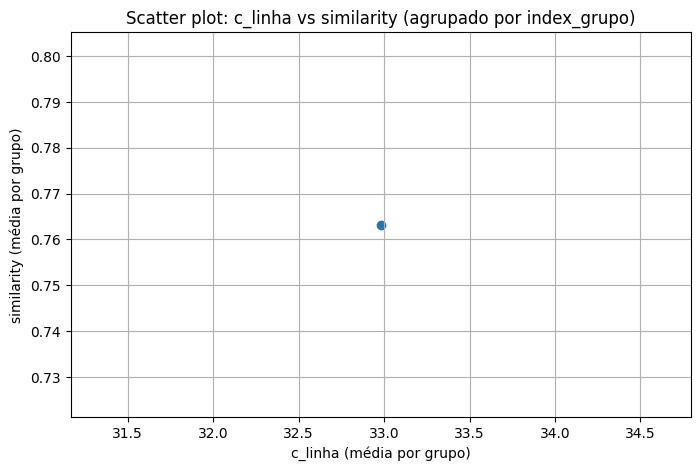

In [258]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(temp['c_linha'], temp['similarity'])
plt.xlabel('c_linha (média por grupo)')
plt.ylabel('similarity (média por grupo)')
plt.title('Scatter plot: c_linha vs similarity (agrupado por index_grupo)')
plt.grid(True)
plt.show()

In [259]:


import plotly.express as px

fig = px.box(
    temp, 
    y='similarity', 
    points="all", 
    title="Boxplot da Similaridade (tudo junto)"
)
fig.show()


In [260]:

# Exibir as primeiras linhas
print(df.head())

# Se quiser agrupar por DiagnosedScenario_name e CandidateScenario_name:
# (agrupa, mas como são únicos não muda nada, só exemplo)
grouped = df.groupby(["DiagnosedScenario_name", "CandidateScenario_name"]).mean(numeric_only=True)
grouped

  DiagnosedScenario_name CandidateScenario_name  grupo  index_grupo  \
0          direita_baixa    candidato_baixo_1_1  baixo            1   
1          direita_baixa    candidato_baixo_1_2  baixo            1   
2          direita_baixa    candidato_baixo_1_3  baixo            1   
3          direita_baixa    candidato_baixo_1_4  baixo            1   
4          direita_baixa    candidato_baixo_1_5  baixo            1   

  index_inner_grupo                                    Candidate_given  \
0                 1  p1 >= 50.13 AND p2 >= 50.13 AND p3 >= 50.13 AN...   
1                 2  p1 >= 47.18 AND p2 >= 47.18 AND p3 >= 47.18 AN...   
2                 3  p1 >= 47.82 AND p2 >= 47.82 AND p3 >= 47.82 AN...   
3                 4  p1 >= 40.40 AND p2 >= 40.40 AND p3 >= 40.40 AN...   
4                 5  p1 >= 48.67 AND p2 >= 48.67 AND p3 >= 48.67 AN...   

   c_linha  similarity  
0    50.13    0.665799  
1    47.18    0.685467  
2    47.82    0.681201  
3    40.40    0.730665  
4  

index_grupo  c_linha  \
DiagnosedScenario_name CandidateScenario_name                         
direita_alta           candidato_alto_1_1              1.0    38.01   
                       candidato_alto_1_10             1.0     4.38   
                       candidato_alto_1_100            1.0    37.46   
                       candidato_alto_1_11             1.0    44.12   
                       candidato_alto_1_12             1.0    79.28   
...                                                    ...      ...   
direita_media          candidato_medio_1_95            1.0    84.50   
                       candidato_medio_1_96            1.0    95.16   
                       candidato_medio_1_97            1.0    67.79   
                       candidato_medio_1_98            1.0    87.16   
                       candidato_medio_1_99            1.0    69.46   

                                               similarity  
DiagnosedScenario_name CandidateScenario_name              
direita_alta           candidato_alto_1_1        0.430125  
                       candidato_alto_1_10       0.396081  
                       candidato_alto_1_100      0.429273  
                       candidato_alto_1_11       0.440703  
                       candidato_alto_1_12       0.622911  
...                                                   ...  
direita_media          candidato_medio_1_95      0.519333  
                       candidato_medio_1_96      0.391413  
                       candidato_medio_1_97      0.719853  
                       candidato_medio_1_98      0.487413  
                       candidato_medio_1_99      0.699813  

[900 rows x 3 columns]

In [261]:
import plotly.express as px

# Filtra primeiro pelo DiagnosedScenario_name
df_direita_baixa = df[df["DiagnosedScenario_name"] == "direita_baixa"]

# Cria uma nova coluna 'tipo' baseada no nome do candidato
def extrair_tipo(nome):
    if "_baixo_" in nome:
        return "baixo"
    elif "_medio_" in nome:
        return "medio"
    elif "_alto_" in nome:
        return "alto"
    else:
        return "outro"

df_direita_baixa["tipo"] = df_direita_baixa["CandidateScenario_name"].apply(extrair_tipo)

# Agora, faz o boxplot com plotly para cada tipo
fig = px.box(df_direita_baixa, x="tipo", y="similarity", points="all", title="Boxplot de Similaridade por Tipo de Candidato")
fig.show()


C:\Users\lucas_alves\AppData\Local\Temp\ipykernel_43616\613142442.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [262]:
import plotly.express as px

# Filtra primeiro pelo DiagnosedScenario_name
df_direita_media = df[df["DiagnosedScenario_name"] == "direita_media"]

# Cria uma nova coluna 'tipo' baseada no nome do candidato
def extrair_tipo(nome):
    if "_baixo_" in nome:
        return "baixo"
    elif "_medio_" in nome:
        return "medio"
    elif "_alto_" in nome:
        return "alto"
    else:
        return "outro"

df_direita_media["tipo"] = df_direita_media["CandidateScenario_name"].apply(extrair_tipo)

# Agora, faz o boxplot com plotly para cada tipo
fig = px.box(df_direita_media, x="tipo", y="similarity", points="all", title="Boxplot de Similaridade por Tipo de Candidato")
fig.show()


C:\Users\lucas_alves\AppData\Local\Temp\ipykernel_43616\1001560272.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [263]:
import plotly.express as px

# Filtra primeiro pelo DiagnosedScenario_name
df_direita_alta = df[df["DiagnosedScenario_name"] == "direita_alta"]

# Cria uma nova coluna 'tipo' baseada no nome do candidato
def extrair_tipo(nome):
    if "_baixo_" in nome:
        return "baixo"
    elif "_medio_" in nome:
        return "medio"
    elif "_alto_" in nome:
        return "alto"
    else:
        return "outro"

df_direita_alta["tipo"] = df_direita_alta["CandidateScenario_name"].apply(extrair_tipo)

# Agora, faz o boxplot com plotly para cada tipo
fig = px.box(df_direita_alta, x="tipo", y="similarity", points="all", title="Boxplot de Similaridade por Tipo de Candidato")
fig.show()


C:\Users\lucas_alves\AppData\Local\Temp\ipykernel_43616\2978841012.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [264]:
import plotly.express as px


# Cria uma nova coluna 'tipo' baseada no nome do candidato
def extrair_tipo(nome):
    if "_baixo_" in nome:
        return "baixo"
    elif "_medio_" in nome:
        return "medio"
    elif "_alto_" in nome:
        return "alto"
    else:
        return "outro"

df["tipo"] = df["CandidateScenario_name"].apply(extrair_tipo)

# Agora, faz o boxplot com plotly para cada tipo
fig = px.box(df, x="tipo", y="similarity", points="all", title="Boxplot de Similaridade por Tipo de Candidato")
fig.show()


,DiagnosedScenario_name,index_grupo,similarity,grupo
0,direita_alta,1,0.916533,alto
1,direita_alta,10,0.926733,medio
2,direita_alta,11,0.926733,medio
3,direita_alta,12,0.875829,alto
4,direita_alta,13,0.923133,baixo
...,...,...,...,...
86,direita_media,5,0.932493,alto
87,direita_media,6,0.932373,alto
88,direita_media,7,0.931899,alto
89,direita_media,8,0.927039,alto


grupo
alto     54
medio    25
baixo    11
Name: count, dtype: int64
